In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pycontrails import Fleet

In [ ]:
# TODO change: 150-350, 200-350, 200-400
# bounds = [150, 350]
# bounds = [200, 350]
bounds = [200, 400]


dff = pd.read_parquet("../data/filed_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000].parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000].parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["NOx", "O3", "CH4", "H2O"])
mask_by_marker(fleeto, ["NOx", "O3", "CH4", "H2O"])

from cane.utils import mask_by_validity_range

mask_by_validity_range(fleetf, ["NOx", "O3", "CH4", "H2O"], bounds)
mask_by_validity_range(fleeto, ["NOx", "O3", "CH4", "H2O"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Fleet contains 4112 flights
Fleet contains 4112 flights
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Bounds of [200, 400] in place for NOx
Bounds of [200, 400] in place for O3
Bounds of [200, 400] in place for CH4
Bounds of [200, 400] in place for H2O
Bounds of [200, 400] in place for NOx
Bounds of [200, 400] in place for O3
Bounds of [200, 400] in place for CH4
Bounds of [200, 400] in place for H2O


In [ ]:
from cane.utils import df_diff

# create aggregates (total)
org_sum = (
    dff[["flight_id", "fuel_burn", "nox", "NOx"]]
    .groupby(["flight_id"]).sum().reset_index()
)
opt_sum = (
    dfo[["flight_id", "fuel_burn", "nox", "NOx"]]
    .groupby(["flight_id"]).sum().reset_index()
)
my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
my_diff = pd.merge(
    my_diff,
    dff.groupby("flight_id").day.first(),
    on="flight_id",
)

In [5]:
my_diff1 = my_diff.copy()

In [9]:
my_diff2 = my_diff.copy()

In [12]:
my_diff3 = my_diff.copy()

In [13]:
my_diff = pd.merge(
    my_diff1[["flight_id", "day", "NOx_reldiff"]],
    my_diff2[["flight_id", "NOx_reldiff"]],
    on="flight_id",
    how="left",
    suffixes=("_1", "_2"),
)

In [14]:
my_diff = pd.merge(
    my_diff,
    my_diff3[["flight_id", "NOx_reldiff"]],
    on="flight_id",
    how="left"
).rename(columns={"NOx_reldiff": "NOx_reldiff_3"})

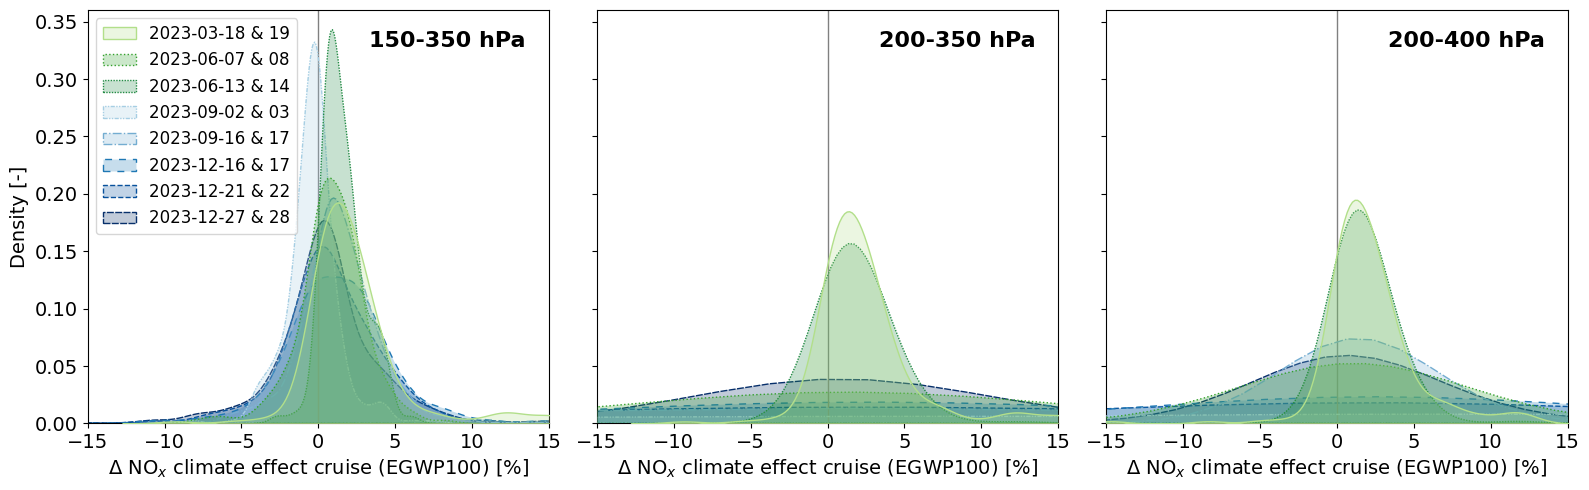

In [ ]:
from cane.labels import friendly_days


def plot_kdes(g, friendly_days, save_path=None):
    """
    Makes a two-panel KDE plot of:
      (a) NOx relative difference
      (b) CO2eq-NOx relative difference
    Each panel has KDEs grouped by 'day' with fill.
    """

    colors = [
        # Group 1 — light green (#b2df8a), only one
        "#b2df8a",
        # Group 2 — dark green (#33a02c)
        "#33a02c", "#238b45",
        # Group 3 — light blue (#a6cee3)
        "#a6cee3", "#74add1",  # much lighter + medium blue
        # Group 4 — dark blue (#1f78b4)
        "#1f78b4", "#08519c", "#08306b"  # progressively darker navy tones
    ]

    linestyles = ["-",
                  ":", (0, (1, 1)),
                  (0, (3, 1, 1, 1, 1, 1)), "-.",
                  (0, (5, 5)), "--", (0, (5, 1))]

    days = sorted(g["day"].unique())

    fig, axes = plt.subplots(1, ncols=3, figsize=(16, 5), sharey=True)

    # plt.subplots_adjust(wspace=4)

    # --------------------------------
    # Helper to avoid duplication
    # --------------------------------
    def plot_panel(ax, xvar, title=None):
        for color, style, day in zip(colors, linestyles, days):
            sns.kdeplot(
                data=g.query("day == @day"),
                x=g.query("day == @day")[xvar] * 100,
                label=friendly_days[day - 1],
                color=color,
                linestyle=style,
                fill=True,
                zorder=8 - day,
                ax=ax
            )

        ax.axvline(0, color="gray", linestyle="solid", linewidth=1)
        ax.set_xlim([-15, 15])
        ax.set_xlabel(title, fontsize=14)
        ax.set_ylabel("Density [-]", fontsize=14)
        ax.tick_params(axis="x", labelsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(False)

    # --------------------------------
    # Plot both panels
    # --------------------------------
    # plot_panel(axes[0], "nox_reldiff", "$\Delta$ NO$_x$ emissions [%]")
    plot_panel(axes[0], "NOx_reldiff_1", "$\Delta$ NO$_x$ climate effect cruise (EGWP100) [%]")
    plot_panel(axes[1], "NOx_reldiff_2", "$\Delta$ NO$_x$ climate effect cruise (EGWP100) [%]")
    plot_panel(axes[2], "NOx_reldiff_3", "$\Delta$ NO$_x$ climate effect cruise (EGWP100) [%]")

    # --------------------------------
    # Add subplot labels
    # --------------------------------
    axes[0].text(
        0.95, 0.95, "150-350 hPa",
        transform=axes[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    axes[1].text(
        0.95, 0.95, "200-350 hPa",
        transform=axes[1].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    axes[2].text(
        0.95, 0.95, "200-400 hPa",
        transform=axes[2].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    # Put legend only on panel (a)
    axes[0].legend(loc="upper left", fontsize=12)
    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()


plot_kdes(my_diff, friendly_days, f"./figures/figC3.png")